<a href="https://colab.research.google.com/github/ajaypadida/OIBSIP-DATASCIENCE/blob/main/Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# 1) Install dependencies
!pip install --quiet kagglehub pandas scikit-learn matplotlib seaborn

# 2) Download (or mount) the dataset
import kagglehub, os
raw_path = kagglehub.dataset_download("saurabh00007/iriscsv")
print("kagglehub gave us:", raw_path)

kagglehub gave us: /kaggle/input/iriscsv


In [7]:
# 3) If it's a zip → unzip, otherwise treat as folder
if os.path.isdir(raw_path):
    data_dir = raw_path
else:
    from zipfile import ZipFile
    data_dir = "/content/iris_data"
    os.makedirs(data_dir, exist_ok=True)
    with ZipFile(raw_path, 'r') as z:
        z.extractall(data_dir)

print("Looking for CSVs in:", data_dir)
csvs = [f for f in os.listdir(data_dir) if f.lower().endswith(".csv")]
print("Found:", csvs)

Looking for CSVs in: /kaggle/input/iriscsv
Found: ['Iris.csv']


In [8]:
# 4) Pick the first CSV and read
import pandas as pd
csv_file = os.path.join(data_dir, csvs[0])
df = pd.read_csv(csv_file)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
# 5) Prepare X/y
X = df.drop(columns=["Id", "Species"], errors="ignore")
y = df["Species"]

In [10]:
# 6) Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [11]:
# 7) Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)


In [12]:
# 8) Fit a RandomForest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# 9) Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



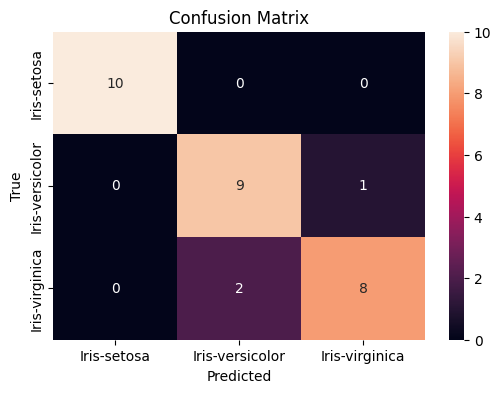

In [14]:
# 10) Confusion matrix plot
import matplotlib.pyplot as plt, seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()